# Spatial-Spectral Schrödinger Eigenmaps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/spatial_spectral_eigenmaps.ipynb)

Schrödinger eigenmaps were designed for hyperspectral images {cite:p}`czaja2013schrodinger,cahill2014spatialspectral`. A Laplacian eigenmap of the pixels only sees their spectra, so two materials that look alike end up in the same place even when they sit in different parts of the scene. A spatial-spectral potential adds what the spectra miss: pixels that are *adjacent and alike* should embed close together. This notebook builds a synthetic hyperspectral cube with exactly that difficulty and compares the two embeddings.

**What you'll learn:**

1. The optimisation problems behind Laplacian and Schrödinger eigenmaps, and the generalised eigenproblems kernellib solves for them.
2. How to build the spatial-spectral potential on the pixel lattice with `spatial_spectral_graph(X, grid_graph(image.shape[:2]))`, sparse throughout.
3. Why Schrödinger eigenmaps separate spectrally near-identical, spatially separate regions that Laplacian eigenmaps merge, measured by k-means ARI.
4. What `normalize_potential` does, and why the trace normalisation makes $\alpha$ transferable between graphs.
5. How to run the same pipeline on a larger cube with approximate neighbours and a sparse eigensolver, and which solver to trust.

## Background

### Laplacian eigenmaps

Let $X \in \mathbb R^{N \times B}$ hold one spectrum per pixel. The **data graph** is the k-NN graph of the spectra, with heat weights $W_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$ ($\sigma$ the median neighbour distance), degree matrix $D = \operatorname{diag}(W\mathbf 1)$ and Laplacian $L = D - W$. Laplacian eigenmaps {cite:p}`belkin2003eigenmaps` look for coordinates $Y \in \mathbb R^{N \times n}$ (rows $y_i$) that keep neighbours close:

$$\min_{Y} \; \sum_{i,j} W_{ij}\, \|y_i - y_j\|^2 = 2\,\mathrm{tr}(Y^\top L Y) \quad \text{s.t.} \quad Y^\top D Y = I, \quad Y^\top D \mathbf 1 = 0.$$

The constraint $Y^\top D Y = I$ fixes the scale and rules out collapsing every point onto one; $Y^\top D\mathbf 1 = 0$ removes the constant solution. The minimisers are the eigenvectors of the generalised eigenproblem

$$L\, y = \lambda D\, y$$

with the $n$ smallest eigenvalues after the trivial $\lambda_0 = 0$. kernellib solves it as the symmetric problem $L_{\mathrm{sym}}\, u = \lambda u$, $L_{\mathrm{sym}} = D^{-1/2} L D^{-1/2}$, and returns $y = D^{-1/2} u$.

### Schrödinger eigenmaps

Schrödinger eigenmaps {cite:p}`czaja2013schrodinger` add a positive semidefinite potential $V$ to the objective:

$$\min_{Y} \; \mathrm{tr}\big(Y^\top (L + \alpha V)\, Y\big) \quad \text{s.t.} \quad Y^\top D Y = I \qquad \Longrightarrow \qquad (L + \alpha V)\, y = \lambda D\, y,$$

solved as $D^{-1/2}(L + \alpha V)D^{-1/2}\, u = \lambda u$, $y = D^{-1/2}u$. A diagonal **barrier** potential, $V = \operatorname{diag}(v)$, adds $\alpha \sum_i v_i \|y_i\|^2$ and pins the points with $v_i > 0$ near the origin. A non-diagonal potential that is itself a graph Laplacian, $V = D_V - W_V$, adds $\alpha \sum_{i \sim j} (W_V)_{ij} \|y_i - y_j\|^2$ and pulls the pairs joined in $W_V$ together {cite:p}`cahill2014spatialspectral`. Such a potential has the constant vector in its null space, so $\lambda_0 = 0$ remains the trivial solution and is dropped (`drop_first=True`); a barrier removes it, so with a barrier every solution is kept (`drop_first=False`).

### The spatial-spectral potential

The spatial-spectral potential of {cite:t}`cahill2014spatialspectral` is a Laplacian-type potential. `spatial_spectral_graph(X, spatial_graph)` keeps the topology of a spatial graph, here the 4-neighbour pixel lattice `grid_graph((H, W))`, and reweights every edge by an RBF kernel of the *spectral* distance of its endpoints (`edge_weights` with `RBF(lengthscale=σ_V)`, unit variance):

$$V = D_V - W_V, \qquad (W_V)_{ij} = \begin{cases} \exp\!\left(-\dfrac{\|x_i - x_j\|^2}{2\sigma_V^2}\right) & \text{pixels } i, j \text{ share a face}, \\[4pt] 0 & \text{otherwise}, \end{cases}$$

with $\sigma_V$ the median of $\|x_i - x_j\|$ over the lattice edges when `bandwidth=None` (and 1 if that median is 0). Then

$$\mathrm{tr}(Y^\top V Y) = \sum_{i \sim j} (W_V)_{ij}\, \|y_i - y_j\|^2$$

pulls neighbouring pixels together only when they also look alike, so it smooths inside a region but not across its boundary. The older `spatial_spectral_potential(X, coordinates, n_neighbors=4)` builds the same kind of potential densely: an $O(N^2)$ search for the 4 nearest pixels by coordinates, the same heat weights on the spectral distances, symmetrised by the maximum.

### Trace normalisation

$L$ and $V$ live on different scales: $\mathrm{tr}(L) = \sum_i D_{ii}$ grows with the number of neighbours and the weights of the data graph, and $\mathrm{tr}(V) = \sum_i (D_V)_{ii} = 2\sum_{i \sim j} (W_V)_{ij}$ with the lattice and its weights. With `normalize_potential=True` (the default) the weight that is actually used is

$$\alpha_{\text{eff}} = \alpha\, \frac{\mathrm{tr}(L)}{\mathrm{tr}(V)},$$

so $\alpha$ is measured relative to the scale of the data graph. `combine_potentials(W, [(V_1, α_1), (V_2, α_2), ...])` applies the same scaling term by term, $\sum_k \alpha_k\, \frac{\mathrm{tr}(L)}{\mathrm{tr}(V_k)}\, V_k$, and is then used with `alpha=1.0, normalize_potential=False`.

### Pipeline

```text
input: cube (H, W, B); k; α; n components
1. X ← rearrange(cube, "h w b -> (h w) b")              # row-major pixels
2. G ← knn_graph(X, k)                                   # spectral data graph, heat weights
3. S ← spatial_spectral_graph(X, grid_graph((H, W)))     # lattice edges, w_ij = exp(−‖x_i − x_j‖² / 2σ_V²)
4. V ← laplacian_operator(S)                             # sparse potential D_V − W_V
5. α_eff ← α · tr(L_G) / tr(V)                           # normalize_potential=True
6. (λ, U) ← n + 1 smallest eigenpairs of D^{-1/2}(L_G + α_eff V) D^{-1/2}   # ARPACK
7. Y ← D^{-1/2} U[:, 1:n+1]                              # drop the constant solution
8. labels ← kmeans(Y, number of regions)
return Y, labels
```

In kernellib, steps 5–7 are `kl.SchrodingerEigenmaps(n_components=n, alpha=α, eigen_solver="arpack").fit(X, V, graph=G)`.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib[neighbors] @ git+https://github.com/jejjohnson/kernellib@main",
            "scikit-learn",
        ],
        check=True,
    )

In [2]:
import importlib.util
import logging
import time
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import einx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

import kernellib as kl


jax.config.update("jax_enable_x64", True)

In [3]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,matplotlib,sklearn,kernellib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.17.1

jax       : 0.11.2
matplotlib: 3.11.2
sklearn   : 1.9.1
kernellib : 0.0.16

Compiler    : Clang 21.1.4 
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## A synthetic hyperspectral cube

The scene has five piecewise-constant regions: the cells of a warped Voronoi diagram with one seed in each corner and one in the centre. Each region has an endmember spectrum, a smooth random curve over 30 bands. Region 1 is a **spectral twin** of region 0: its spectrum differs by a small sinusoid, far less than the noise, but the two regions sit in opposite corners and never touch. The abundances are blurred at the region boundaries to mix neighbouring endmembers, and every pixel gets noise that is correlated across bands.

In [4]:
N_REGIONS = 5
N_BANDS = 30


def make_cube(height, width, *, noise=0.02, seed=0):
    """Synthetic (height, width, N_BANDS) cube, its region map and endmembers."""
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:height, 0:width].astype(float) * (60.0 / height)
    wy = yy + 4 * np.sin(2 * np.pi * xx / 40)
    wx = xx + 4 * np.sin(2 * np.pi * yy / 35)
    seeds = np.array([[12, 12], [48, 48], [12, 48], [48, 12], [30, 30]], float)
    dist2 = einx.subtract("h w, k -> k h w", wy, seeds[:, 0]) ** 2
    dist2 += einx.subtract("h w, k -> k h w", wx, seeds[:, 1]) ** 2
    labels = einx.id("1 h w -> h w", einx.argmin("[k] h w", dist2))

    bands = np.linspace(0.0, 1.0, N_BANDS)
    basis = np.cos(np.pi * einx.multiply("m, b -> m b", np.arange(6), bands))
    coefs = rng.normal(size=(N_REGIONS, 6))
    curves = einx.dot("k m, m b -> k b", coefs, basis)
    centred = einx.subtract("k b, k -> k b", curves, einx.mean("k b -> k", curves))
    scaled = einx.divide("k b, k -> k b", centred, einx.std("k b -> k", curves))
    endmembers = 0.5 + 0.15 * scaled
    endmembers[1] = endmembers[0] + 0.01 * np.sin(3 * np.pi * bands)  # the twin

    sharp = einx.equal("h w, k -> k h w", labels, np.arange(N_REGIONS))
    sigma_px = 0.7 * height / 60
    blurred = np.stack([gaussian_filter(m.astype(float), sigma_px) for m in sharp])
    total = einx.sum("k h w -> h w", blurred)
    abundance = einx.divide("k h w, h w -> k h w", blurred, total)
    cube = einx.dot("k h w, k b -> h w b", abundance, endmembers)

    gap = einx.subtract("a, b -> a b", bands, bands)
    corr = np.exp(-(gap**2) / (2 * 0.1**2)) + 1e-8 * np.eye(N_BANDS)
    chol = np.linalg.cholesky(corr)
    white = rng.normal(size=(height, width, N_BANDS))
    cube = cube + noise * einx.dot("h w c, b c -> h w b", white, chol)
    return cube, labels, endmembers


cube, truth_map, endmembers = make_cube(60, 60)
H, W, B = cube.shape
truth = einx.id("h w -> (h w)", truth_map)
twins = np.isin(truth, [0, 1])

diff = einx.subtract("a b, c b -> a c b", endmembers, endmembers)
pair_dist = np.sqrt(einx.sum("a c b -> a c", diff**2))
upper = pair_dist[np.triu_indices(N_REGIONS, 1)]  # upper[0] is the twin pair
print(f"cube: {H} x {W} pixels x {B} bands, region sizes {np.bincount(truth)}")
print(f"spectral distance, twins 0-1:          {pair_dist[0, 1]:.3f}")
print(f"spectral distance, closest other pair: {np.min(upper[1:]):.3f}")
print(f"expected noise norm per pixel:         {0.02 * np.sqrt(B):.3f}")

cube: 60 x 60 pixels x 30 bands, region sizes [754 732 720 759 635]
spectral distance, twins 0-1:          0.038
spectral distance, closest other pair: 0.427
expected noise norm per pixel:         0.110


The twins are about three times closer to each other than the noise moves a single pixel, while every other pair of regions is well separated. A false-colour composite (bands 25, 15 and 5 as red, green and blue) shows the problem: regions 0 and 1 have the same colour.

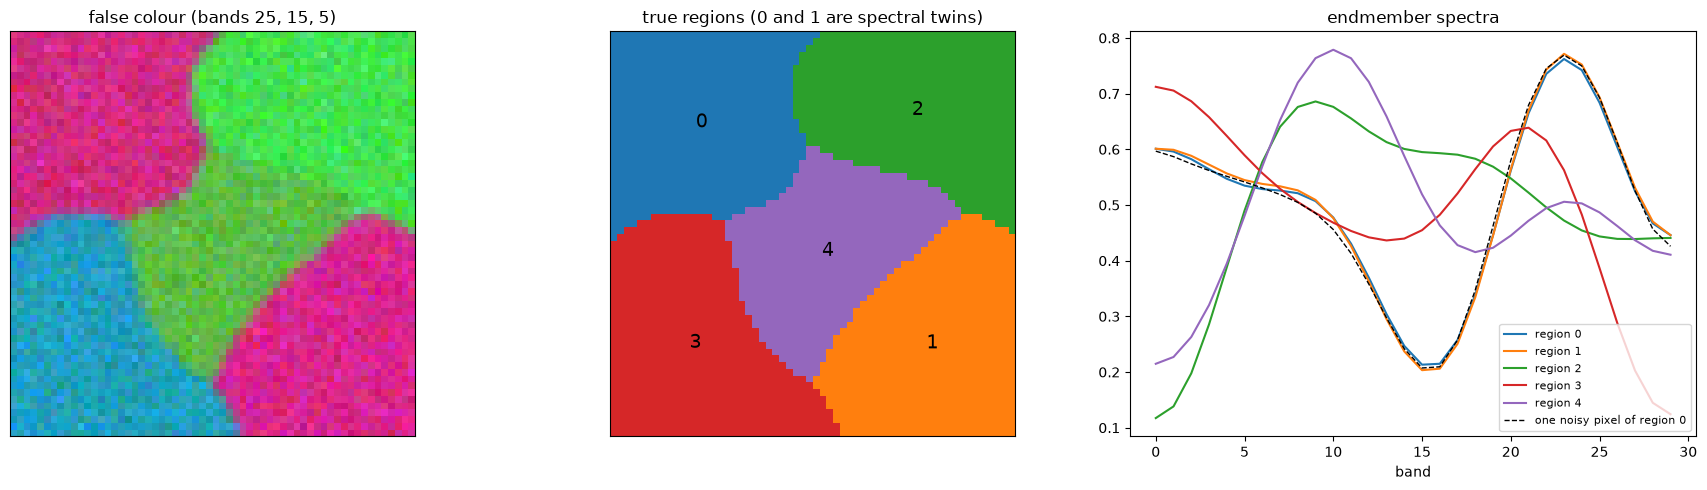

In [5]:
def false_colour(cube):
    rgb = cube[..., [25, 15, 5]]
    lo = einx.min("h w c -> c", rgb)
    hi = einx.max("h w c -> c", rgb)
    return einx.divide(
        "h w c, c -> h w c", einx.subtract("h w c, c -> h w c", rgb, lo), hi - lo
    )


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(false_colour(cube))
axes[0].set_title("false colour (bands 25, 15, 5)")
im = axes[1].imshow(truth_map, cmap="tab10", vmin=0, vmax=9)
for k in range(N_REGIONS):
    ys, xs = np.nonzero(truth_map == k)
    axes[1].text(xs.mean(), ys.mean(), str(k), ha="center", va="center", fontsize=14)
axes[1].set_title("true regions (0 and 1 are spectral twins)")
for k in range(N_REGIONS):
    axes[2].plot(endmembers[k], color=f"C{k}", label=f"region {k}")
axes[2].plot(cube[5, 5], "k--", lw=1, label="one noisy pixel of region 0")
axes[2].set_xlabel("band")
axes[2].set_title("endmember spectra")
axes[2].legend(fontsize=8)
for ax in axes[:2]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## The data graph and the spatial-spectral potential

Both graphs are sparse `Graph`s. The **data graph** is the 10-NN graph of the spectra (`knn_graph`, heat weights, bandwidth the median neighbour distance); it ignores where the pixels are. The **potential** is the Laplacian of the spatial-spectral graph on the pixel lattice: `grid_graph((H, W))` supplies the 4-neighbour topology and `spatial_spectral_graph` reweights it by spectral similarity. Its `laplacian_operator()` is a sparse gaussx operator, which `SchrodingerEigenmaps.fit` takes directly.

In [6]:
X = jnp.asarray(einx.id("h w b -> (h w) b", cube))
spectral = kl.knn_graph(X, 10)
lattice = kl.grid_graph((H, W))
cahill = kl.spatial_spectral_graph(X, lattice)
V = cahill.laplacian_operator()

senders, receivers = cahill.topology.senders, cahill.topology.receivers
edge_dist = jnp.sqrt(einx.sum("e b -> e", (X[senders] - X[receivers]) ** 2))
sigma_v = jnp.median(edge_dist)
print(f"data graph: {spectral.topology.n_edges} edges")
print(f"lattice:    {cahill.topology.n_edges} edges, sigma_V = {float(sigma_v):.3f}")
print(f"potential:  {type(V).__name__}, shape {V.out_size()} x {V.in_size()}")

data graph: 25872 edges
lattice:    7080 edges, sigma_V = 0.151
potential:  SparseOperator, shape 3600 x 3600


Across a region boundary the spectral distance is large and the edge weight is close to zero, so the potential barely couples different regions; inside a region it is a nearly uniform lattice. The histogram of lattice edge weights shows the two populations: the median weight is about 0.6 inside a region and about $10^{-3}$ across a true boundary.

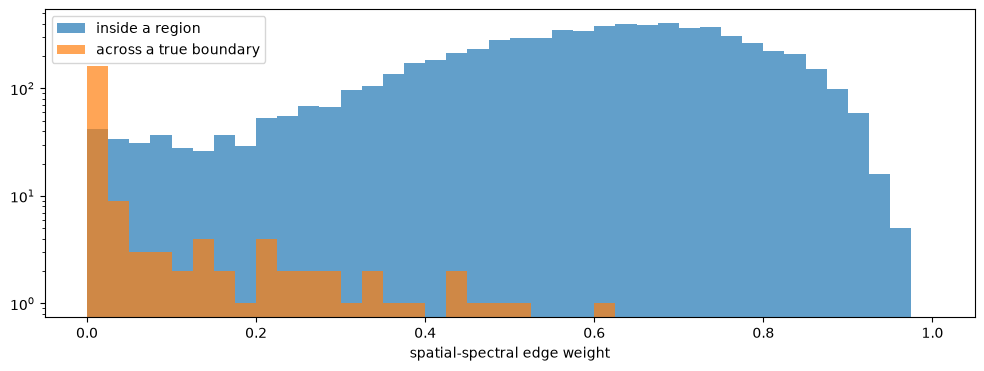

median weight inside a region 0.613, across a boundary 1.23e-03


In [7]:
is_boundary = truth[np.asarray(senders)] != truth[np.asarray(receivers)]
weights = np.asarray(cahill.weights)
fig, ax = plt.subplots(figsize=(12, 4))
bins = np.linspace(0, 1, 41)
ax.hist(weights[~is_boundary], bins=bins, alpha=0.7, label="inside a region")
ax.hist(weights[is_boundary], bins=bins, alpha=0.7, label="across a true boundary")
ax.set_yscale("log")
ax.set_xlabel("spatial-spectral edge weight")
ax.legend()
plt.show()
inside = np.median(weights[~is_boundary])
across = np.median(weights[is_boundary])
print(f"median weight inside a region {inside:.3f}, across a boundary {across:.2e}")

The older `spatial_spectral_potential(X, coordinates, n_neighbors=4)` builds the same kind of potential densely, from an $O(N^2)$ nearest-neighbour search on the pixel coordinates. With the same bandwidth the two agree away from the image border. At the border they differ: an edge or corner pixel has fewer than 4 lattice neighbours, so its 4 nearest pixels include diagonal ones, and the symmetrised k-NN graph adds those diagonal edges to the pixels next to it as well. The dense matrix also takes $N^2$ memory (100 MB in float64 at $N = 3600$), while the lattice graph stores 7080 edges.

In [8]:
rows, cols = np.mgrid[0:H, 0:W]
flat_rc = [einx.id("h w -> (h w)", a) for a in (rows, cols)]
coords = jnp.asarray(np.column_stack(flat_rc), dtype=float)
V_dense = kl.spatial_spectral_potential(X, coords, n_neighbors=4, bandwidth=sigma_v)
V_lattice = kl.spatial_spectral_graph(
    X, lattice, bandwidth=sigma_v
).laplacian_operator()
gap = jnp.abs(V_dense - V_lattice.as_matrix())
depth = np.minimum(np.minimum(rows, H - 1 - rows), np.minimum(cols, W - 1 - cols))
deep = einx.id("h w -> (h w)", depth >= 2)
print(f"max |difference|, pixels >= 2 from the border: {float(jnp.max(gap[deep])):.2e}")
print(
    f"max |difference|, the two outer rings:         {float(jnp.max(gap[~deep])):.2e}"
)
del V_dense, gap

max |difference|, pixels >= 2 from the border: 8.88e-16


max |difference|, the two outer rings:         1.78e+00


## Laplacian vs Schrödinger eigenmaps

Both embeddings use four components, on the same data graph, solved with ARPACK on the sparse operators (`eigen_solver="arpack"`). The Schrödinger eigenmap uses $\alpha = 10$ with the default normalisation.

In [9]:
N_COMPONENTS = 4
ALPHA = 10.0

start = time.perf_counter()
le = kl.LaplacianEigenmaps(
    n_components=N_COMPONENTS, eigen_solver="arpack", random_state=0
).fit(X, graph=spectral)
t_le = time.perf_counter() - start

start = time.perf_counter()
se = kl.SchrodingerEigenmaps(
    n_components=N_COMPONENTS, alpha=ALPHA, eigen_solver="arpack", random_state=0
).fit(X, V, graph=spectral)
t_se = time.perf_counter() - start
print(f"Laplacian eigenmaps:   {t_le:.2f} s, eigenvalues {np.round(le.eigenvalues, 4)}")
print(f"Schrödinger eigenmaps: {t_se:.2f} s, eigenvalues {np.round(se.eigenvalues, 4)}")

Laplacian eigenmaps:   2.16 s, eigenvalues [0.     0.     0.0002 0.0111]
Schrödinger eigenmaps: 1.38 s, eigenvalues [0.0023 0.0032 0.0369 0.8245]


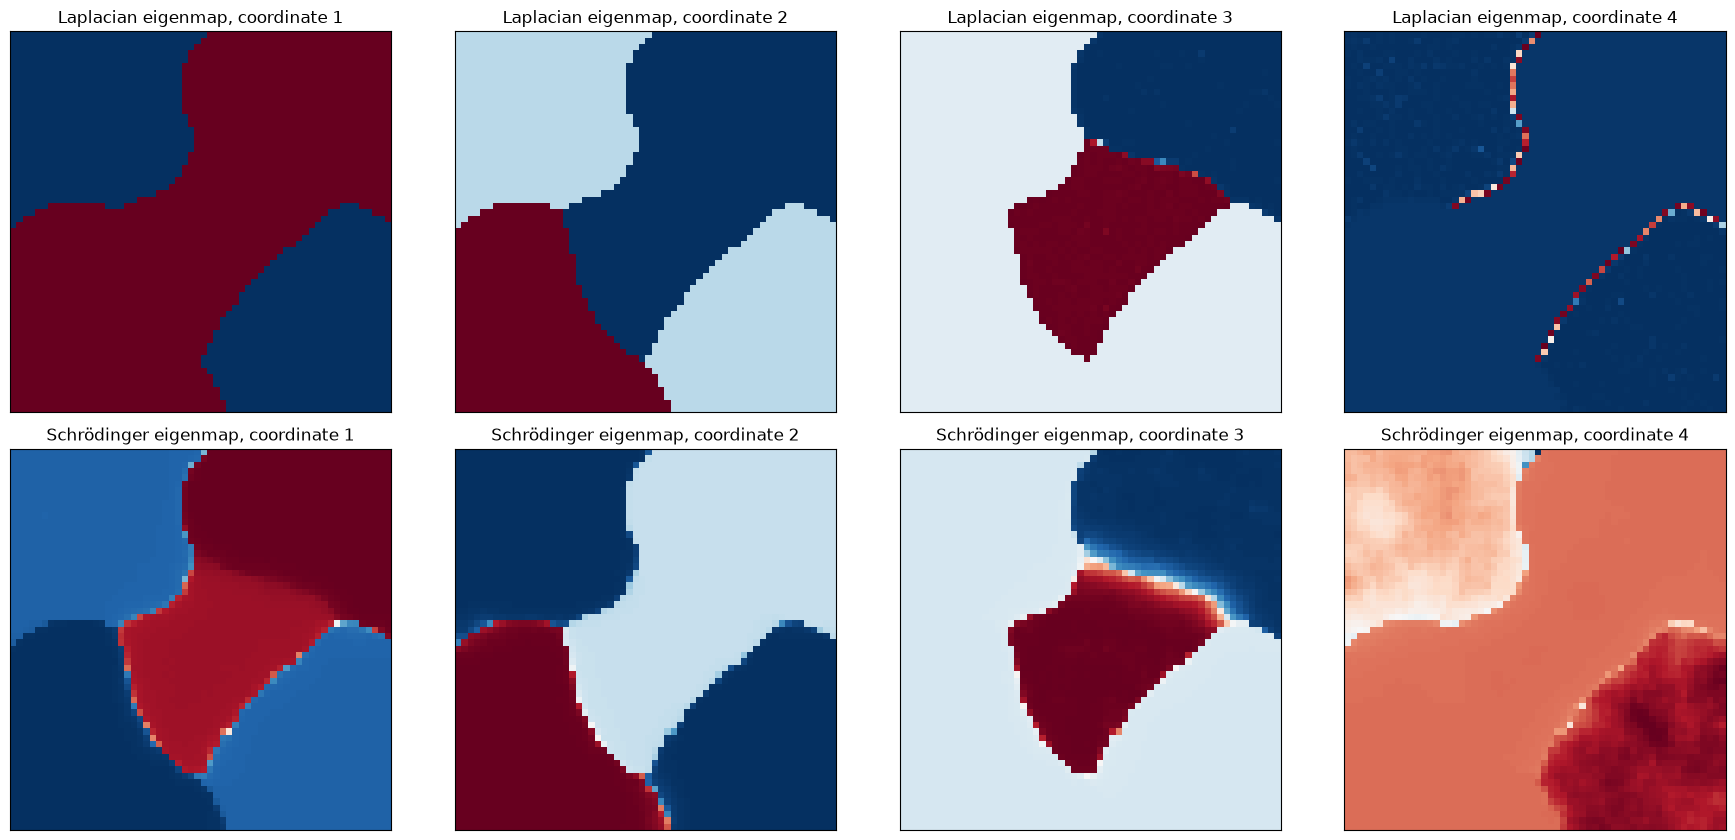

In [10]:
fig, axes = plt.subplots(2, N_COMPONENTS, figsize=(18, 8.5))
for row, (model, name) in enumerate([(le, "Laplacian"), (se, "Schrödinger")]):
    images = einx.id("(h w) n -> n h w", model.embedding, h=H)
    for j in range(N_COMPONENTS):
        ax = axes[row, j]
        ax.imshow(images[j], cmap="RdBu_r")
        ax.set_title(f"{name} eigenmap, coordinate {j + 1}")
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

**Numerics: why ARPACK.** At $N = 3600$ a dense `eigh` of the $N \times N$ problem is still possible ($O(N^3)$ time, 100 MB in float64), and the dense path is the one that is differentiable in the edge weights. The sweep below needs 40 fits, though, and the data graph, the lattice and the potential are all sparse, so every fit here uses `eigen_solver="arpack"`. That path converts the operators to SciPy and runs `eigsh` on $cI - S$, $S = D^{-1/2}(L + \alpha_{\text{eff}} V)D^{-1/2}$, with $c$ a Gershgorin bound on the spectrum of $S$: the smallest eigenvalues of $S$ become the largest of $cI - S$, where implicitly restarted Lanczos converges best. ARPACK iterates until its residual tolerance is met. The JAX path `eigen_solver="lanczos"` runs a single Krylov space of fixed size (about `n_components + 200`) with no residual check, and issue [#159](https://github.com/jejjohnson/kernellib/issues/159) reports a case at $N = 22\,500$ where it returns wrong eigenpairs without warning. Until that is fixed, prefer ARPACK for Schrödinger eigenmaps on large graphs, or check $\|S u - \lambda u\|$ yourself. Everything runs in float64 (`jax_enable_x64`): several of the eigenvalues printed above are below $10^{-3}$, and the Laplacian ones round to zero at four decimals, so float32, with a relative precision of about $10^{-7}$ on a spectrum that extends to $c$, would resolve them only to a few digits.

The Laplacian coordinates are functions of the spectrum alone. They are piecewise constant over the spectral classes, and the twins in the top-left and bottom-right corners take the same value in every coordinate; the fourth coordinate is spent on the mixed pixels along two of the boundaries. The first three Schrödinger coordinates carry the same class structure, and the fourth gives the twins different values: the potential does not couple the two corners, so splitting them costs almost nothing in $\mathrm{tr}(Y^\top V Y)$.

## Clustering the embeddings

k-means with five clusters on each embedding, scored against the true regions with the adjusted Rand index (ARI; 1 is perfect, 0 is chance). The second column scores only the pixels of the twin regions 0 and 1: a value near 0 means the clustering cannot tell the twins apart.

In [11]:
def cluster(embedding, seed=0):
    km = KMeans(N_REGIONS, n_init=10, random_state=seed)
    return km.fit_predict(np.asarray(embedding))


def scores(pred):
    return adjusted_rand_score(truth, pred), adjusted_rand_score(
        truth[twins], pred[twins]
    )


pred_le, pred_se = cluster(le.embedding), cluster(se.embedding)
pred_raw = cluster(X)
print(f"{'embedding':<28}{'ARI (all)':>10}{'ARI (twins)':>13}")
for name, pred in [
    ("raw spectra (30 bands)", pred_raw),
    ("Laplacian eigenmap", pred_le),
    (f"Schrödinger, alpha={ALPHA:g}", pred_se),
]:
    a_all, a_twin = scores(pred)
    print(f"{name:<28}{a_all:>10.3f}{a_twin:>13.3f}")

embedding                    ARI (all)  ARI (twins)
raw spectra (30 bands)           0.751       -0.000
Laplacian eigenmap               0.765       -0.000
Schrödinger, alpha=10            0.987        0.959


Clustering the raw spectra or the Laplacian eigenmap gives an ARI of about 0.75 to 0.77, and 0 on the twins: they are one cluster, and k-means spends its fifth cluster elsewhere (on the Laplacian eigenmap, on the thin band of mixed boundary pixels). The Schrödinger eigenmap reaches 0.987 overall and 0.959 on the twins, so the definition of done of this example holds: on the spectrally similar, spatially separate regions the Schrödinger ARI is well above the Laplacian one.

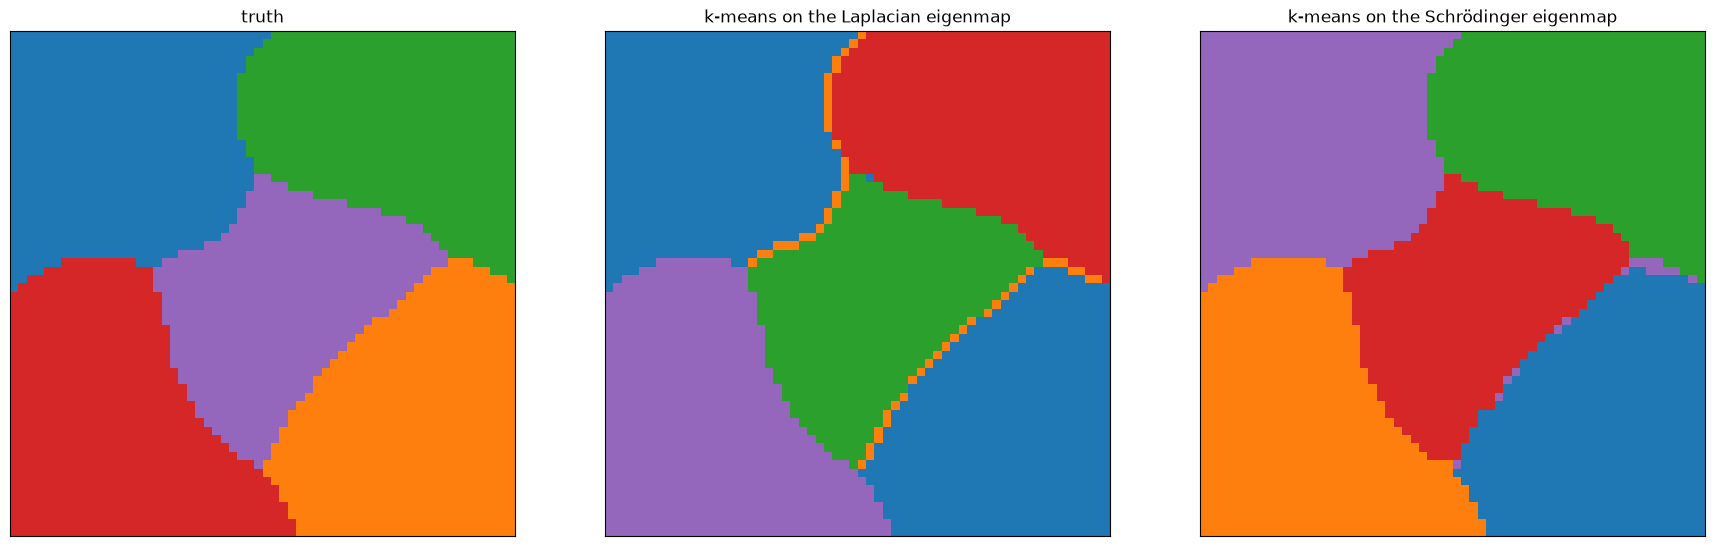

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
panels = [
    (truth_map, "truth"),
    (einx.id("(h w) -> h w", pred_le, h=H), "k-means on the Laplacian eigenmap"),
    (einx.id("(h w) -> h w", pred_se, h=H), "k-means on the Schrödinger eigenmap"),
]
for ax, (image, title) in zip(axes, panels, strict=True):
    ax.imshow(image, cmap="tab10", vmin=0, vmax=9)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## A barrier potential from a few labelled pixels

Prior knowledge can also enter through labels. `barrier_potential` is diagonal: it adds $\alpha \sum_{i \in \text{idx}} \|y_i\|^2$ and pins the chosen pixels near the origin. Here eight pixels of region 0 are pinned. A barrier removes the constant solution, so `drop_first=False` keeps the first solution, and one extra component keeps the comparison at four informative ones. On its own, the barrier acts through the data graph, which links every pixel of region 0 to pixels of region 1; combined with the spatial-spectral potential (`combine_potentials`, each term normalised by $\mathrm{tr}(L)/\mathrm{tr}(V_k)$), it has spatial support.

In [13]:
rng = np.random.default_rng(1)
pinned = jnp.asarray(rng.choice(np.flatnonzero(truth == 0), size=8, replace=False))
barrier = kl.barrier_potential(H * W, pinned)
barrier_kwargs = dict(
    n_components=N_COMPONENTS + 1,
    drop_first=False,
    eigen_solver="arpack",
    random_state=0,
)
se_barrier = kl.SchrodingerEigenmaps(alpha=1.0, **barrier_kwargs)
se_barrier = se_barrier.fit(X, barrier, graph=spectral)
both = kl.combine_potentials(spectral, [(V, ALPHA), (barrier, 1.0)])
se_both = kl.SchrodingerEigenmaps(
    alpha=1.0, normalize_potential=False, **barrier_kwargs
)
se_both = se_both.fit(X, both, graph=spectral)
for name, model in [
    ("barrier only", se_barrier),
    ("spatial-spectral + barrier", se_both),
]:
    a_all, a_twin = scores(cluster(model.embedding))
    print(f"{name:<28} ARI (all) {a_all:.3f}   ARI (twins) {a_twin:.3f}")

barrier only                 ARI (all) 0.762   ARI (twins) 0.000
spatial-spectral + barrier   ARI (all) 0.992   ARI (twins) 0.980


The barrier alone does not separate the twins (ARI 0 on them): pinning pixels of region 0 drags region 1 along through the data graph. Together with the spatial-spectral potential the ARI is 0.992 overall and 0.980 on the twins, about what the spatial-spectral potential achieves alone; here the labels add little.

## Sweeping α, with and without normalisation

How large must $\alpha$ be? Without normalisation the answer depends on the scale of $L$, which changes with the data graph: a 30-NN graph has roughly three times the total degree of a 10-NN graph, so the same raw $\alpha$ is relatively three times weaker. With `normalize_potential=True` the effective weight is $\alpha\,\mathrm{tr}(L)/\mathrm{tr}(V)$, and the transition happens at the same $\alpha$ on both graphs.

In [14]:
alphas = np.logspace(0, 3, 10)
graphs = {k: (spectral if k == 10 else kl.knn_graph(X, k)) for k in (10, 30)}
trace_v = float(jnp.sum(cahill.laplacian_operator().diagonal()))
sweep = {}
start = time.perf_counter()
for k, graph in graphs.items():
    trace_l = float(jnp.sum(graph.laplacian_operator().diagonal()))
    print(
        f"k = {k}: tr(L) = {trace_l:.0f}, tr(V) = {trace_v:.0f}, "
        f"ratio {trace_l / trace_v:.2f}"
    )
    for normalize in (True, False):
        curve = []
        for alpha in alphas:
            model = kl.SchrodingerEigenmaps(
                n_components=N_COMPONENTS,
                alpha=float(alpha),
                normalize_potential=normalize,
                eigen_solver="arpack",
                random_state=0,
            ).fit(X, V, graph=graph)
            curve.append(scores(cluster(model.embedding)))
        sweep[k, normalize] = np.array(curve)
print(f"{2 * 2 * alphas.size} fits in {time.perf_counter() - start:.1f} s")

k = 10: tr(L) = 28640, tr(V) = 8117, ratio 3.53


k = 30: tr(L) = 83934, tr(V) = 8117, ratio 10.34


40 fits in 42.1 s


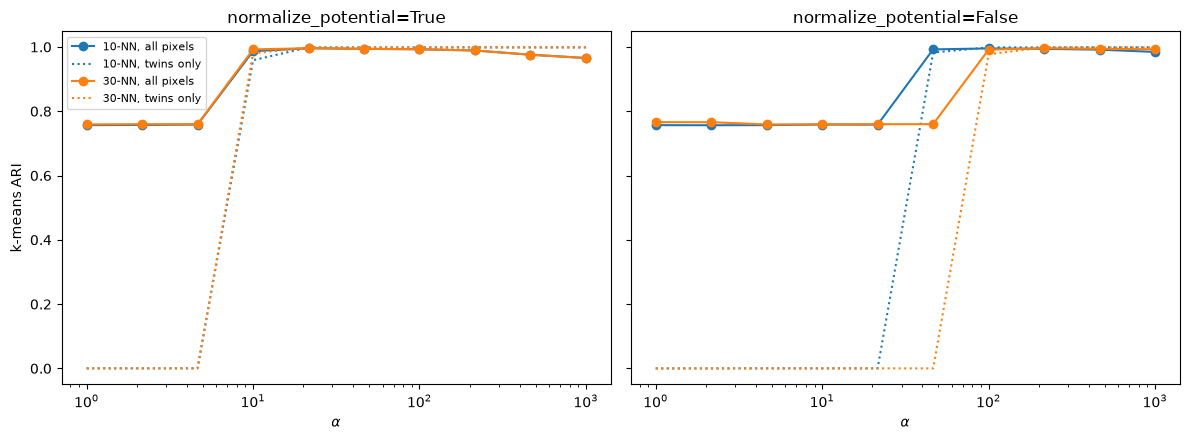

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, normalize in zip(axes, (True, False), strict=True):
    for k, color in [(10, "C0"), (30, "C1")]:
        curve = sweep[k, normalize]
        ax.semilogx(alphas, curve[:, 0], "-o", color=color, label=f"{k}-NN, all pixels")
        ax.semilogx(alphas, curve[:, 1], ":", color=color, label=f"{k}-NN, twins only")
    ax.set_xlabel(r"$\alpha$")
    ax.set_title(f"normalize_potential={normalize}")
axes[0].set_ylabel("k-means ARI")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
def threshold(curve, level=0.9):
    """Smallest alpha at which the twins-only ARI reaches `level`."""
    hit = np.flatnonzero(curve[:, 1] >= level)
    return alphas[hit[0]] if hit.size else np.nan


for normalize in (True, False):
    t10, t30 = threshold(sweep[10, normalize]), threshold(sweep[30, normalize])
    print(
        f"normalize_potential={normalize!s:<5}: twins separated from alpha = "
        f"{t10:g} (10-NN), {t30:g} (30-NN)"
    )

normalize_potential=True : twins separated from alpha = 10 (10-NN), 10 (30-NN)
normalize_potential=False: twins separated from alpha = 46.4159 (10-NN), 100 (30-NN)


With normalisation the two data graphs behave identically: the twins separate from $\alpha = 10$ on both. Without it the threshold moves from $\alpha \approx 46$ on the 10-NN graph to $\alpha = 100$ on the 30-NN graph, because $\mathrm{tr}(L)$ is 2.9 times larger on the latter (ratios $\mathrm{tr}(L)/\mathrm{tr}(V)$ of 3.53 and 10.34). The normalisation divides out exactly that scale, so a value of $\alpha$ found on one data graph carries over to another.

## At scale

Nothing above formed an $N \times N$ matrix: the data graph, the lattice and the potential are sparse, and ARPACK only needs matrix-vector products. On a larger cube the remaining cost is the neighbour search. `backend="pynndescent"` (extra `kernellib[neighbors]`; the estimators take the same switch as `neighbors_backend=`) replaces the exact $O(N^2)$ search by approximate NN-descent. The next cell uses it when it is installed and falls back to the exact JAX search otherwise, and prints which one produced the committed outputs. A small warm-up call keeps numba's one-off compilation out of the timing.

The cube is the same scene at $150 \times 150$ pixels, 2.5 times the resolution. Two values of $\alpha$ are run: the $\alpha = 10$ used above, and $\alpha = 30$.

In [17]:
big, big_truth_map, _ = make_cube(150, 150, seed=0)
Hb, Wb, _ = big.shape
Xb = jnp.asarray(einx.id("h w b -> (h w) b", big))
big_truth = einx.id("h w -> (h w)", big_truth_map)
big_twins = np.isin(big_truth, [0, 1])
backend = "pynndescent" if importlib.util.find_spec("pynndescent") else "exact"
if backend == "pynndescent":
    kl.knn_graph(Xb[:500], 10, backend=backend, random_state=0)  # numba warm-up

timings = {}
start = time.perf_counter()
big_spectral = kl.knn_graph(Xb, 10, backend=backend, random_state=0)
timings["10-NN graph"] = time.perf_counter() - start
start = time.perf_counter()
big_v = kl.spatial_spectral_graph(Xb, kl.grid_graph((Hb, Wb))).laplacian_operator()
timings["spatial-spectral potential"] = time.perf_counter() - start
start = time.perf_counter()
big_models = {
    "Laplacian": kl.LaplacianEigenmaps(
        n_components=N_COMPONENTS, eigen_solver="arpack", random_state=0
    ).fit(Xb, graph=big_spectral)
}
timings["Laplacian eigenmaps"] = time.perf_counter() - start
for alpha in (10.0, 30.0):
    start = time.perf_counter()
    big_models[f"Schrödinger, alpha={alpha:g}"] = kl.SchrodingerEigenmaps(
        n_components=N_COMPONENTS, alpha=alpha, eigen_solver="arpack", random_state=0
    ).fit(Xb, big_v, graph=big_spectral)
    timings[f"Schrödinger eigenmaps, alpha={alpha:g}"] = time.perf_counter() - start

print(
    f"N = {Hb} x {Wb} = {Hb * Wb} pixels; backend = {backend!r}, "
    "eigen_solver = 'arpack'"
)
for name, seconds in timings.items():
    print(f"  {name:<36}{seconds:6.1f} s")
big_preds = {}
for name, model in big_models.items():
    big_preds[name] = cluster(model.embedding)
    a_all = adjusted_rand_score(big_truth, big_preds[name])
    a_twin = adjusted_rand_score(big_truth[big_twins], big_preds[name][big_twins])
    print(f"  {name:<28} ARI (all) {a_all:.3f}   ARI (twins) {a_twin:.3f}")

N = 150 x 150 = 22500 pixels; backend = 'pynndescent', eigen_solver = 'arpack'
  10-NN graph                            3.7 s
  spatial-spectral potential             2.2 s
  Laplacian eigenmaps                    2.4 s
  Schrödinger eigenmaps, alpha=10       11.1 s
  Schrödinger eigenmaps, alpha=30       63.5 s


  Laplacian                    ARI (all) 0.750   ARI (twins) -0.000


  Schrödinger, alpha=10        ARI (all) 0.724   ARI (twins) -0.000


  Schrödinger, alpha=30        ARI (all) 0.964   ARI (twins) 0.930


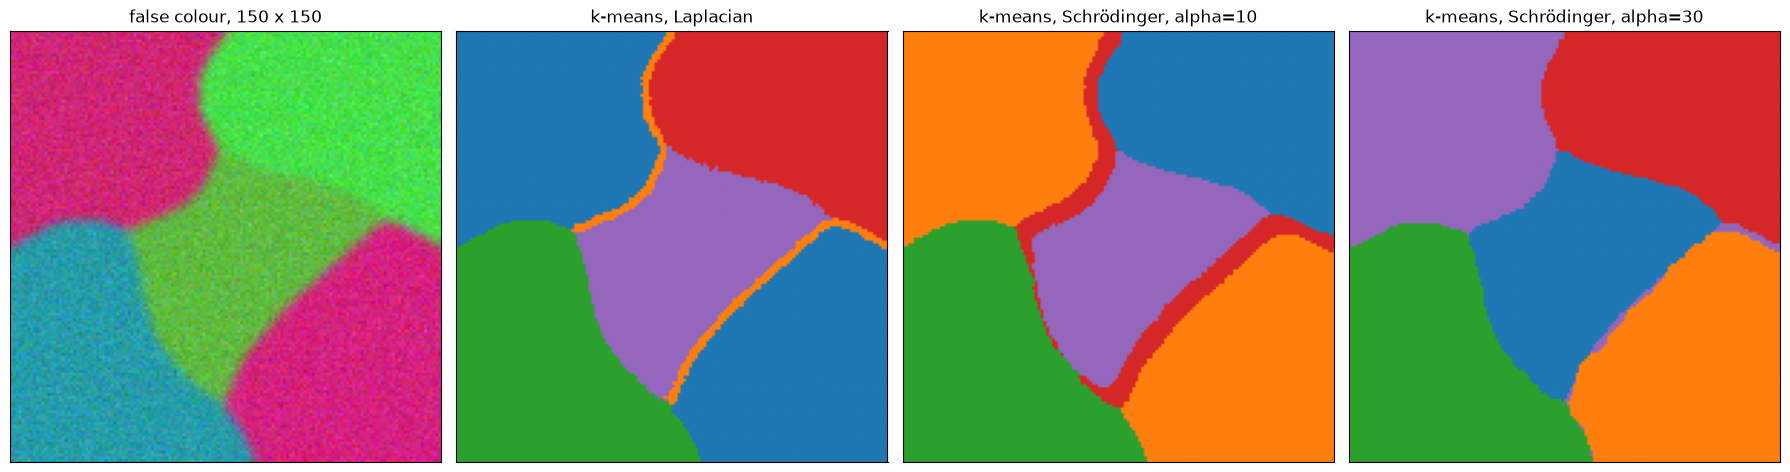

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(false_colour(big))
axes[0].set_title("false colour, 150 x 150")
for ax, (name, pred) in zip(axes[1:], big_preds.items(), strict=True):
    ax.imshow(einx.id("(h w) -> h w", pred, h=Hb), cmap="tab10", vmin=0, vmax=9)
    ax.set_title(f"k-means, {name}")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

At $150 \times 150$ the Laplacian eigenmap again merges the twins (ARI 0 on them). The $\alpha = 10$ found on the $60 \times 60$ cube is no longer enough, while $\alpha = 30$ separates them (ARI 0.964 overall, 0.930 on the twins). The trace normalisation makes $\alpha$ transferable between data graphs on the same lattice, as the sweep showed, but not across resolutions: at 2.5 times the resolution each region spans 2.5 times as many pixels, the smooth within-region modes of the lattice potential get cheaper, and a stronger potential is needed to prefer splitting the twins over them. Sweep $\alpha$ again when the image size changes.

The timings also show the cost of a larger $\alpha$: the ARPACK path finds the smallest eigenvalues of $S = D^{-1/2}(L + \alpha V)D^{-1/2}$ as the largest of $cI - S$, with $c$ a bound on the spectrum, and no shift-invert. A stronger potential widens the spectrum, so the smallest eigenvalues sit relatively closer together and converge more slowly: the $\alpha = 30$ solve takes several times longer than the $\alpha = 10$ one. The neighbour search is no longer the bottleneck.

**Numerics at scale.** Three caveats apply to this configuration. (1) *Solver.* ARPACK's convergence rate depends on the gaps between the wanted eigenvalues relative to $c$; a shift-invert solve (`eigsh(S, sigma=0)` with a sparse factorisation of $S$) would converge in a few iterations, but kernellib does not use it yet. The JAX Lanczos path is faster per fit but not reliable here ([#159](https://github.com/jejjohnson/kernellib/issues/159)). (2) *Neighbour backend dtype.* `knn_graph(..., backend="pynndescent")` returns float32 edge weights even under x64 ([#158](https://github.com/jejjohnson/kernellib/issues/158)). On the ARPACK path this only limits the data-graph weights to float32 precision, because SciPy promotes the sum $L + \alpha V$ to float64; on the Lanczos path, mixing the float32 graph with the float64 potential fails with "Incompatible linear operator structures". `graph.reweight(graph.weights.astype(jnp.float64))` avoids both. (3) *Approximate neighbours.* NN-descent returns approximate neighbours, so the data graph, and with it the embedding, can differ slightly from the exact k-NN graph; with `random_state` fixed it is reproducible.

## Summary

- Laplacian eigenmaps solve $L y = \lambda D y$; Schrödinger eigenmaps solve $(L + \alpha V)\,y = \lambda D y$, and a Laplacian-type potential $V$ adds $\alpha\sum_{i \sim j}(W_V)_{ij}\|y_i - y_j\|^2$ to the objective.
- `spatial_spectral_graph(X, grid_graph(image.shape[:2]))` is the spatial-spectral potential of {cite:t}`cahill2014spatialspectral` as a sparse graph; its `laplacian_operator()` goes straight into `SchrodingerEigenmaps.fit`, alongside a precomputed data graph via `graph=`.
- A Laplacian eigenmap only sees spectra, so it cannot separate two regions that look alike. The spatial-spectral potential couples pixels only within spatially connected, spectrally homogeneous patches, which is what separates the twins.
- With `normalize_potential=True`, $\alpha_{\text{eff}} = \alpha\,\mathrm{tr}(L)/\mathrm{tr}(V)$ and $\alpha$ transfers between data graphs; without it, the useful range of $\alpha$ moves with the graph's total degree. It does not transfer across image resolutions.
- With sparse graphs and `eigen_solver="arpack"`, the pipeline scales to images where an $N \times N$ matrix would not fit; avoid `"lanczos"` for Schrödinger eigenmaps until [#159](https://github.com/jejjohnson/kernellib/issues/159) is fixed.